In [ ]:
#@title Instalación
#@title Instalación
!pip install dandi
!dandi download https://gui.dandiarchive.org/#/dandiset/000128
!pip install pynwb h5py


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.8/395.8 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.0/45.0 MB 18.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 194.1/194.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 6.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.6/118.6 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 55.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.9/341.9 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/53.1 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 284.1/284.1 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/

#0. Configuración inicial

In [ ]:
#@title 0.1 Librerias
import os
import h5py
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from collections import Counter
from scipy.ndimage import gaussian_filter1d
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [ ]:
#@title 0.2 Paletas y Path

#Paletas
C = {
    'bg':     '#0d1117',
    'panel':  '#161b22',
    'border': '#30363d',
    'teal':   '#39d0c8',
    'amber':  '#f0a500',
    'red':    '#e05c5c',
    'blue':   '#58a6ff',
    'gray':   '#8b949e',
    'white':  '#e6edf3',
}

plt.rcParams.update({
    'figure.facecolor':  C['bg'],
    'axes.facecolor':    C['panel'],
    'axes.edgecolor':    C['border'],
    'axes.labelcolor':   C['white'],
    'xtick.color':       C['gray'],
    'ytick.color':       C['gray'],
    'text.color':        C['white'],
    'grid.color':        C['border'],
    'grid.linewidth':    0.6,
    'font.family':       'monospace',
    'axes.spines.top':   False,
    'axes.spines.right': False,
})

OUT = '/content/eda_outputs'
os.makedirs(OUT, exist_ok=True)

#Path
PATH = '/content/000128/sub-Jenkins/sub-Jenkins_ses-full_desc-train_behavior+ecephys.nwb'

f_data = h5py.File(PATH, 'r')

# 1. Pre-procesamiento

In [ ]:
#@title 1.1 Enventanamiento

#Trials'  time info
target_on = f_data['intervals/trials/target_on_time'][()]  #Inicio de planificación
go_cue = f_data['intervals/trials/go_cue_time'][()]  #Señal de iniciar movimiento
move_onset  = f_data['intervals/trials/move_onset_time'][()] #Inicio del movimiento

#índices de trials válidos
delay = f_data['intervals/trials/delay'][()]
valid_idx = np.where(delay >= 0)[0] #índices de los trials válidos

print(f"Trials totales          : {len(delay)}")
print(f"Trials válidos (>=400ms): {len(valid_idx)}")
print(f"Trials descartados      : {len(delay) - len(valid_idx)}")

#Filtro de data válida
delay_valid = delay[valid_idx]
target_on_valid  = target_on[valid_idx]   #Tiempo de inicio de planificación, válidos
go_cue_valid     = go_cue[valid_idx]      #Tiempo de fin de planificación, válidos
move_onset_valid = move_onset[valid_idx]  #Tiempo de inicio de movimiento, válidos

print("\n")

#Mostrar resultad
df = pd.DataFrame({
    'target_on (s)' : target_on_valid[:8],
    'delay (s)'     : delay_valid[:8]/1000,
    'go_cue (s)'    : go_cue_valid[:8],
    'Reaction(s)'   : move_onset_valid[:8] - go_cue_valid[:8],
    'move_onset (s)': move_onset_valid[:8],
})

print(df.T.to_string())



Trials totales          : 2295
Trials válidos (>=400ms): 2281
Trials descartados      : 14


                    0      1      2       3       4       5       6       7
target_on (s)   0.880  4.291  7.471  10.853  13.687  16.415  19.520  23.007
delay (s)       0.598  0.448  0.498   0.482   0.548   0.765   0.881   0.832
go_cue (s)      1.478  4.739  7.969  11.335  14.235  17.180  20.401  23.839
Reaction(s)     0.427  0.541  0.377   0.417   0.272   0.319   0.433   0.392
move_onset (s)  1.905  5.280  8.346  11.752  14.507  17.499  20.834  24.231


In [ ]:
#@title 1.2. Extracción de neuronas

#Extraer data
spike_times       = f_data['units/spike_times'][()] #Tiempo de spike de cada neurona
spike_idx = f_data['units/spike_times_index'][()] #idx donde termina una neurona e inicia otra


#Parámetros
BIN_SIZE  = 0.001   # 1ms
N_BINS    = 500     # 400ms
N_NEURONS = 182
N_TRIALS  = len(valid_idx)

#Sperar spikes por neurona
neuron_spikes = []
for k in range(N_NEURONS):
    start_k = spike_idx[k-1] if k > 0 else 0
    end_k   = spike_idx[k]
    neuron_spikes.append(spike_times[start_k:end_k])

#Representación
print(f"{'Neurona':>8}  {'Spikes totales':>15}  {'Spikes en ventana de 400ms':>18}")
print("─" * 55)
for k in range(8):
    total = len(neuron_spikes[k])
    en_ventana = 0
    for i in valid_idx:
        t_start = target_on[i]
        t_end   = target_on[i] + 0.400
        mask    = (neuron_spikes[k] >= t_start) & (neuron_spikes[k] < t_end)
        en_ventana += mask.sum()
    print(f"{k:>8}  {total:>15}  {en_ventana:>18}")



 Neurona   Spikes totales  Spikes en ventana de 400ms
───────────────────────────────────────────────────────
       0             5811                1134
       1             6522                 261
       2             4276                 201
       3             1545                 561
       4            12141                3522
       5             3950                 376
       6            12087                1578
       7            12592                2579


Shape tensor binario : (2281, 500, 182)
Densidad de spikes   : 0.212%
Total spikes en X    : 440960




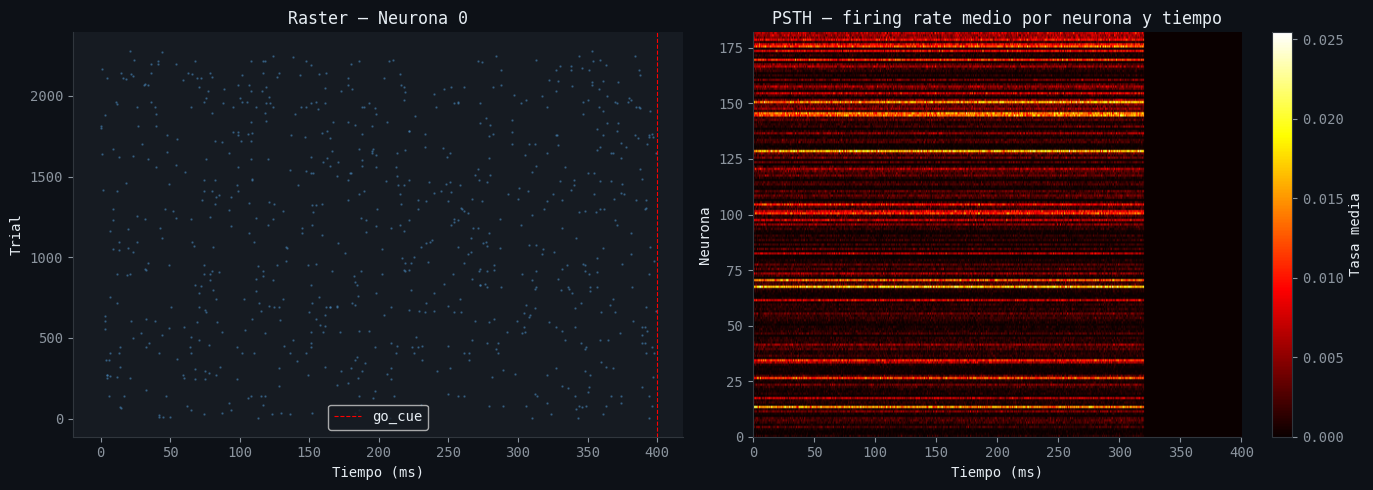

In [ ]:
#@title 1.3 Tensor binario

#Entrada a training
X = np.zeros((N_TRIALS, N_BINS, N_NEURONS), dtype=np.float32)

for t, i in enumerate(valid_idx):
  #Ventana de 400ms anterior al go_cue
    t_start = go_cue[i] - 0.400
    t_end   = go_cue[i]

  #Obtener todos los spikes en ese rango
    for k in range(N_NEURONS):
       #Solo spikes dentro del rango
        spikes_k         = neuron_spikes[k]
        mask             = (spikes_k >= t_start) & (spikes_k < t_end)
        spikes_in_window = spikes_k[mask]

       #Si no hay spikes detectados, continuar a la siguiente
        if len(spikes_in_window) == 0:
            continue

       # Convertir timestamps absolutos → índices de bin relativos a t_start
        bin_indices = ((spikes_in_window - t_start) / BIN_SIZE).astype(int)
        bin_indices = np.clip(bin_indices, 0, N_BINS - 1)

      # Marcar como 1 los bins donde hubo spike
        X[t, bin_indices, k] = 1.0

print(f"Shape tensor binario : {X.shape}")
print(f"Densidad de spikes   : {X.mean()*100:.3f}%")
print(f"Total spikes en X    : {int(X.sum())}")

print("\n")

#Representación
# ── 1. Raster plot: Actividad de una neurona en el tiempo ─────────────────────────
NEURONA = 0
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
spike_times_raster = np.where(X[:, :, NEURONA] == 1)
ax.scatter(spike_times_raster[1], spike_times_raster[0],
           s=0.5, color='steelblue', alpha=0.5)
ax.set_xlabel("Tiempo (ms)")
ax.set_ylabel("Trial")
ax.set_title(f"Raster — Neurona {NEURONA}")
ax.axvline(400, color='red', lw=0.8, ls='--', label='go_cue')
ax.legend()

# ── 2. PSTH: firing rate promedio por neurona ─────────────────────────────
ax = axes[1]
psth = X.mean(axis=0)  # (400, 182) — promedio sobre trials
im   = ax.imshow(psth.T, aspect='auto', origin='lower',
                 extent=[0, 400, 0, 182], cmap='hot')
ax.set_xlabel("Tiempo (ms)")
ax.set_ylabel("Neurona")
ax.set_title("PSTH — firing rate medio por neurona y tiempo")
plt.colorbar(im, ax=ax, label='Tasa media')

plt.tight_layout()
plt.show()


In [ ]:
#@title 1.4 Filtro Gaussiano

#Filtrado
X_smooth = gaussian_filter1d(X, sigma=10, axis=1, mode='constant', cval=0.0)

#Resultados
print(f"Shape tensor suavizado : {X_smooth.shape}")
print(f"Valor mínimo           : {X_smooth.min():.6f}")
print(f"Valor máximo           : {X_smooth.max():.6f}")
print(f"Valor medio            : {X_smooth.mean():.6f}")



Shape tensor suavizado : (2281, 500, 182)
Valor mínimo           : 0.000000
Valor máximo           : 0.292729
Valor medio            : 0.002103


Trial más activo  : 505
Neurona más activa: 67


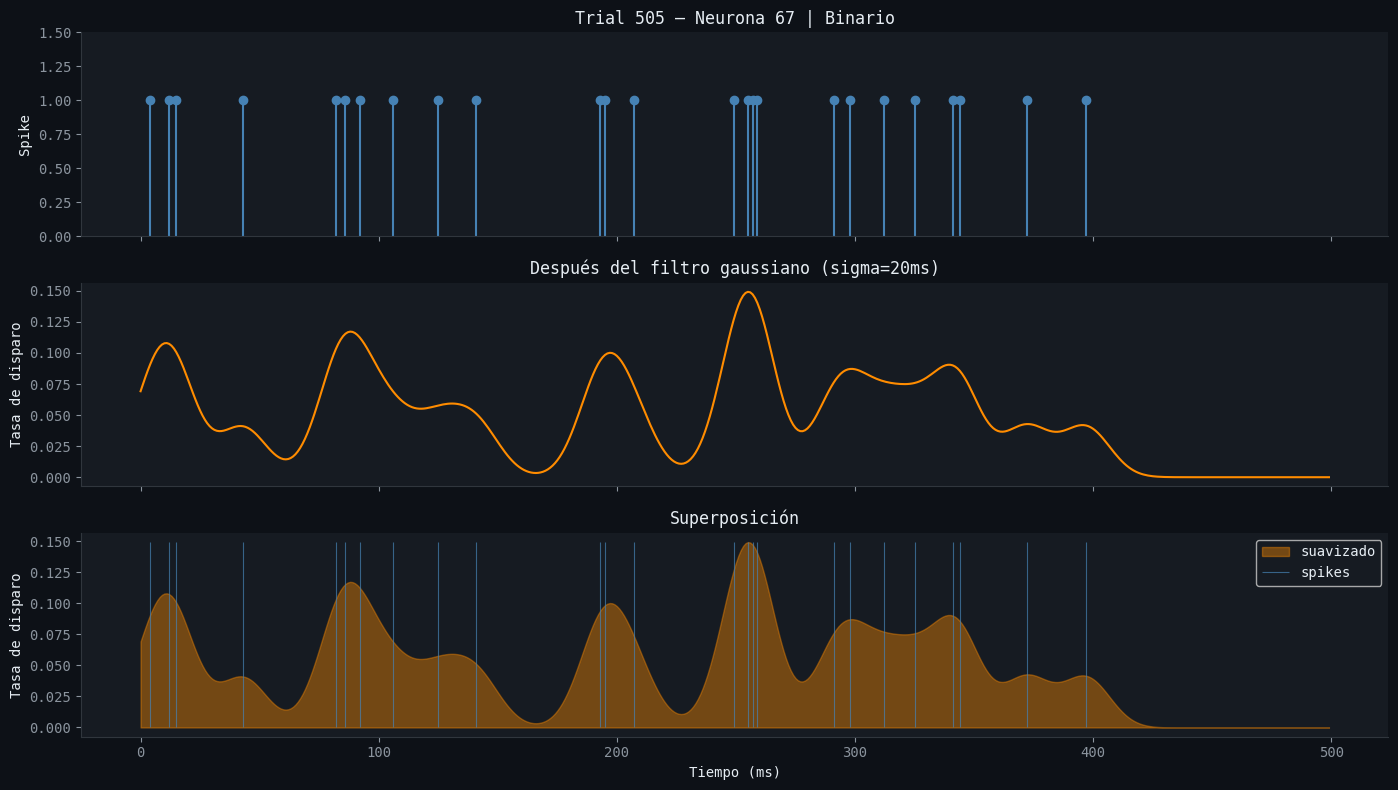

In [ ]:
#@title 1.5 Representación del filtro
#Encontrar neurona con más actividad
actividad   = X.sum(axis=1)                                                # (1967, 182)
trial_idx, neurona_idx = np.unravel_index(actividad.argmax(), actividad.shape)
print(f"Trial más activo  : {trial_idx}")
print(f"Neurona más activa: {neurona_idx}")

#Parámetros
TRIAL   = trial_idx
NEURONA = neurona_idx
spike_positions = np.where(X[TRIAL, :, NEURONA])[0]  # índices donde hay spike

#Plotting
fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

# 1. Binario
axes[0].stem(spike_positions,
             np.ones(len(spike_positions)),  # len() devuelve int
             linefmt='steelblue', markerfmt='o', basefmt=' ')
axes[0].set_ylabel("Spike")
axes[0].set_title(f"Trial {TRIAL} — Neurona {NEURONA} | Binario")
axes[0].set_ylim(0, 1.5)

# 2. Suavizado
axes[1].plot(X_smooth[TRIAL, :, NEURONA], color='darkorange', lw=1.5)
axes[1].set_ylabel("Tasa de disparo")
axes[1].set_title("Después del filtro gaussiano (sigma=20ms)")

# 3. Superposición
axes[2].fill_between(range(500), X_smooth[TRIAL, :, NEURONA],
                     color='darkorange', alpha=0.4, label='suavizado')
axes[2].vlines(spike_positions, 0,
               X_smooth[TRIAL, :, NEURONA].max(),
               color='steelblue', alpha=0.7, lw=0.8, label='spikes')
axes[2].set_xlabel("Tiempo (ms)")
axes[2].set_ylabel("Tasa de disparo")
axes[2].set_title("Superposición")
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
#@title 1.6 Extracción de clases

#Data
cursor_ts    = f_data['processing/behavior/cursor_pos/timestamps'][()]
cursor_pos   = f_data['processing/behavior/cursor_pos/data'][()]

# ── Calcular ángulo por trial ──────────────────────────────────────────────
# Ventana: 500ms después de move_onset = 50 muestras a 100Hz
WINDOW_SAMPLES = 50

angles_deg = []
for i in valid_idx:
    idx_start = np.searchsorted(cursor_ts, move_onset[i]) #Sincronizar tiempo de inicio
    idx_end   = idx_start + WINDOW_SAMPLES

    # Verificar que no nos salimos del array
    if idx_end >= len(cursor_pos):
        angles_deg.append(np.nan)
        continue

    hand_start = cursor_pos[idx_start]
    hand_end   = cursor_pos[idx_end]

    dx = hand_end[0] - hand_start[0]
    dy = hand_end[1] - hand_start[1]
    angles_deg.append(np.degrees(np.arctan2(dy, dx)))

angles_deg = np.array(angles_deg)

print(f"Ángulos calculados : {len(angles_deg)}")
print(f"NaN encontrados    : {np.isnan(angles_deg).sum()}")
print("\n")

# Descartar NaN (trials al borde del array)
valid_mask = ~np.isnan(angles_deg)
angles_deg = angles_deg[valid_mask]

#Asignar a 8 clases
bin_edges  = np.array([-180, -157.5, -112.5, -67.5, -22.5, 22.5, 67.5, 112.5, 157.5, 180])

direction_names = {
    0: 'Clase 4  (±180°)',
    1: 'Clase 5  (-135°)',
    2: 'Clase 6  (-90°)',
    3: 'Clase 7  (-45°)',
    4: 'Clase 0  (0°)',
    5: 'Clase 1  (45°)',
    6: 'Clase 2  (90°)',
    7: 'Clase 3  (135°)'
}

angles_clipped = np.clip(angles_deg, -179.99, 179.99)
bin_idx        = np.digitize(angles_clipped, bin_edges[1:-1]) % 8

# Presentar distribución
counts = Counter(bin_idx)
total  = len(bin_idx)

print(f"{'Clase':>6}  {'Dirección':<20}  {'N':>6}  {'%':>6}")
print("─" * 46)
for cls in range(8):
    n = counts.get(cls, 0)
    print(f"{cls:>6}  {direction_names[cls]:<20}  {n:>6}  {n/total*100:>5.1f}%")
print("─" * 46)
print(f"{'Total':<28}  {total:>6}  100.0%")


Ángulos calculados : 2281
NaN encontrados    : 0


 Clase  Dirección                  N       %
──────────────────────────────────────────────
     0  Clase 4  (±180°)          99    4.3%
     1  Clase 5  (-135°)         206    9.0%
     2  Clase 6  (-90°)          351   15.4%
     3  Clase 7  (-45°)           47    2.1%
     4  Clase 0  (0°)            382   16.7%
     5  Clase 1  (45°)           790   34.6%
     6  Clase 2  (90°)           234   10.3%
     7  Clase 3  (135°)          172    7.5%
──────────────────────────────────────────────
Total                           2281  100.0%


#2. Reducción de dimensionalidad

In [ ]:
#@title 2.1 Cálculo

# Aplanar modos trial y tiempo → (182, 1967*400) = (182, 786800)
# Esto expone la varianza de cada neurona a través de todos los trials y tiempos
X_unfold_neural = X_smooth.transpose(2, 0, 1).reshape(182, -1)
U, s, Vt = np.linalg.svd(X_unfold_neural, full_matrices=False)
explained = np.cumsum(s**2) / np.sum(s**2) # Varianza acumulada por cada neurona

#Resultados
r85 = np.searchsorted(explained, 0.85) + 1
r90 = np.searchsorted(explained, 0.90) + 1
r95 = np.searchsorted(explained, 0.95) + 1
r100 = np.searchsorted(explained, 1.00) + 1
print(f"R para 85%: {r85} | 90%: {r90} | 95%: {r95} | 100%: {r100}")

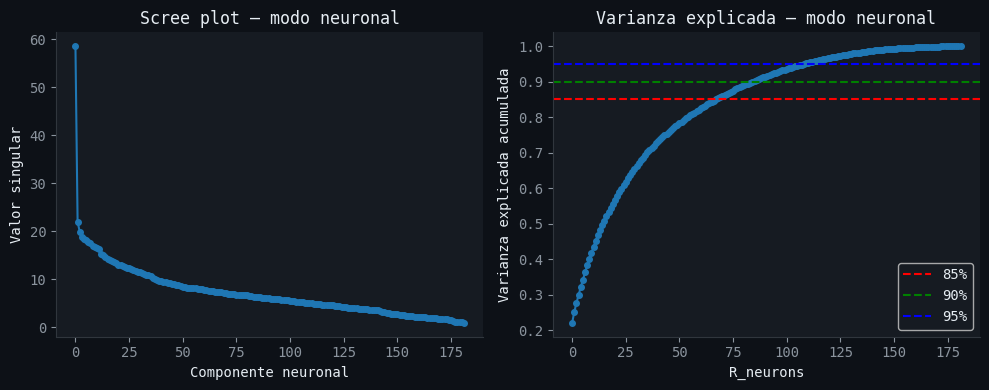


X_reduced shape: (2281, 500, 69)


In [ ]:
#@title 2.2 Representación

#Plotting
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(s, 'o-', markersize=4)
plt.xlabel('Componente neuronal')
plt.ylabel('Valor singular')
plt.title('Scree plot — modo neuronal')

plt.subplot(1, 2, 2)
plt.plot(explained, 'o-', markersize=4)
plt.axhline(y=0.85, color='r', linestyle='--', label='85%')
plt.axhline(y=0.90, color='g', linestyle='--', label='90%')
plt.axhline(y=0.95, color='b', linestyle='--', label='95%')
plt.xlabel('R_neurons')
plt.ylabel('Varianza explicada acumulada')
plt.legend()
plt.title('Varianza explicada — modo neuronal')
plt.tight_layout()
plt.show()

# Proyección Tucker
R_neurons = r85 #Se escoge el 90% de la varianza
C = U[:, :R_neurons] #Columnas ortogonales
X_reduced = X_smooth @ C

#Resultados
print(f"\nX_reduced shape: {X_reduced.shape}")

#3. Entrenamiento LSTM

In [ ]:
#@title 3.1 Separación de la data

#Variables iniciales
indices = np.arange(len(bin_idx))

# Split estratificado
#70% train
train_idx, temp_idx = train_test_split(indices, test_size=0.30,
                                       random_state=42, stratify=bin_idx)

#15% validación 15% test
val_idx, test_idx   = train_test_split(temp_idx, test_size=0.50,
                                       random_state=42, stratify=bin_idx[temp_idx])

# Normalización solo a train
mean = X_reduced[train_idx].mean(axis=(0, 1), keepdims=True)
std  = X_reduced[train_idx].std(axis=(0, 1), keepdims=True)

X_train = (X_reduced[train_idx] - mean) / (std + 1e-8)
X_val   = (X_reduced[val_idx]   - mean) / (std + 1e-8)
X_test  = (X_reduced[test_idx]  - mean) / (std + 1e-8)

y_train = bin_idx[train_idx]
y_val   = bin_idx[val_idx]
y_test  = bin_idx[test_idx]

# --- VERIFICACIÓN ---
angles = ['0°', '45°', '90°', '135°', '±180°', '-135°', '-90°', '-45°']

print(f"Total trials: {len(indices)} = {len(train_idx)} + {len(val_idx)} + {len(test_idx)}")
print(f"Proporciones: {len(train_idx)/len(indices):.2f} / {len(val_idx)/len(indices):.2f} / {len(test_idx)/len(indices):.2f}")
print()

# Distribución por clase en cada split — debe ser proporcional en los tres
print(f"{'Clase':<12} {'Total':>6} {'Train':>6} {'Val':>6} {'Test':>6}")
print("-" * 42)
for cls in range(8):
    n_total = (bin_idx == cls).sum()
    n_train = (y_train == cls).sum()
    n_val   = (y_val   == cls).sum()
    n_test  = (y_test  == cls).sum()
    print(f"{angles[cls]:<12} {n_total:>6} {n_train:>6} {n_val:>6} {n_test:>6}")

print()
# Verificar no hay solapamiento entre splits
assert len(np.intersect1d(train_idx, val_idx))  == 0, "FUGA: train y val comparten índices"
assert len(np.intersect1d(train_idx, test_idx)) == 0, "FUGA: train y test comparten índices"
assert len(np.intersect1d(val_idx,   test_idx)) == 0, "FUGA: val y test comparten índices"
print("Sin solapamiento entre splits: OK")

# Verificar normalización
print(f"\nX_train media: {X_train.mean():.4f} (esperado ≈ 0)")
print(f"X_train std:   {X_train.std():.4f}  (esperado ≈ 1)")
print(f"X_val media:   {X_val.mean():.4f}   (esperado ≈ 0, no exacto)")
print(f"X_test media:  {X_test.mean():.4f}  (esperado ≈ 0, no exacto)")

#Tamaño del resultado
print(f"\nX_train shape: {X_train.shape}")
print(f"X_val shape:   {X_val.shape}")
print(f"X_test shape:  {X_test.shape}")

print(f"\ny_train shape: {y_train.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"y_test shape:  {y_test.shape}")

Total trials: 2281 = 1596 + 342 + 343
Proporciones: 0.70 / 0.15 / 0.15

Clase         Total  Train    Val   Test
------------------------------------------
0°               99     69     15     15
45°             206    144     31     31
90°             351    246     53     52
135°             47     33      7      7
±180°           382    267     57     58
-135°           790    553    118    119
-90°            234    164     35     35
-45°            172    120     26     26

Sin solapamiento entre splits: OK

X_train media: -0.0000 (esperado ≈ 0)
X_train std:   1.0003  (esperado ≈ 1)
X_val media:   0.0040   (esperado ≈ 0, no exacto)
X_test media:  -0.0014  (esperado ≈ 0, no exacto)

X_train shape: (1596, 500, 69)
X_val shape:   (342, 500, 69)
X_test shape:  (343, 500, 69)

y_train shape: (1596,)
y_val shape:   (342,)
y_test shape:  (343,)


In [ ]:
#@title 3.2 Tratamiento de desbalance
#Cost-sensitive balance
weights = compute_class_weight(class_weight='balanced',
                               classes=np.arange(8),
                               y=y_train)
class_weights = torch.tensor(weights, dtype=torch.float32)
print(f"\nClass weights: {np.round(weights, 3)}")


Class weights: [2.891 1.385 0.811 6.045 0.747 0.361 1.216 1.662]


In [ ]:
#@title 3.3 Hiperparámetros
# --- HIPERPARÁMETROS ---
LSTM1_UNITS   = 64
LSTM2_UNITS   = 32
DROPOUT1_RATE = 0.5
DROPOUT2_RATE = 0.5
L2_REG        = 0.005
LEARNING_RATE = 0.0001
EPOCHS        = 200
BATCH_SIZE    = 32
PATIENCE_ES   = 50
PATIENCE_LR   = 7

INPUT_SIZE = X_train.shape[2]  # R_neurons
NUM_CLASSES = 8

print(f"Input size (R_neurons): {INPUT_SIZE}")
print(f"LSTM: {LSTM1_UNITS} → {LSTM2_UNITS} → {NUM_CLASSES}")

Input size (R_neurons): 69
LSTM: 64 → 32 → 8


In [ ]:
#@title 3.4 Arquitectura
class MotorLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm1 = nn.LSTM(input_size=INPUT_SIZE, hidden_size=LSTM1_UNITS,
                             batch_first=True,dropout=0)
        self.drop1 = nn.Dropout(DROPOUT1_RATE)
        self.lstm2 = nn.LSTM(input_size=LSTM1_UNITS, hidden_size=LSTM2_UNITS,
                             batch_first=True)
        self.drop2 = nn.Dropout(DROPOUT2_RATE)
        self.fc    = nn.Linear(LSTM2_UNITS*3, NUM_CLASSES)

    def forward(self, x):
        x, _ = self.lstm1(x)
        x = self.drop1(x)
        x, _ = self.lstm2(x)
        x = self.drop2(x)
        x_last = x[:, -1, :]
        x_mean = x.mean(dim=1)
        x_max, _ = x.max(dim=1)
        x = torch.cat([x_last, x_mean, x_max], dim=1)  # (batch, 96)
        return self.fc(x)

In [ ]:
#@title 3.5 Optimizador
# --- DATALOADERS ---
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
y_val_t   = torch.tensor(y_val,   dtype=torch.long)
y_test_t  = torch.tensor(y_test,  dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t),
                          batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val_t,   y_val_t),
                          batch_size=BATCH_SIZE, shuffle=False)

# --- MODELO, LOSS, OPTIMIZER ---
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model     = MotorLSTM().to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights.to(device))
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE,
                             weight_decay=L2_REG)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min',
                                                        patience=PATIENCE_LR,
                                                        factor=0.5)

print(f"\nModelo en: {device}")
print(f"Parámetros totales: {sum(p.numel() for p in model.parameters()):,}")


Modelo en: cuda
Parámetros totales: 47,880


In [ ]:
#@title 3.6 Entrenamiento
# --- TRAINING LOOP ---
best_val_loss = float('inf')
best_val_acc = 0.0
patience_counter = 0
history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(EPOCHS):
    # Training
    model.train()
    train_loss, train_correct, train_total = 0, 0, 0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        train_loss  += loss.item() * len(y_batch)
        preds        = logits.argmax(dim=1)
        train_correct += (preds == y_batch).sum().item()
        train_total  += len(y_batch)

    # Validation
    model.eval()
    val_loss, val_correct, val_total = 0, 0, 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss   = criterion(logits, y_batch)

            val_loss    += loss.item() * len(y_batch)
            preds        = logits.argmax(dim=1)
            val_correct += (preds == y_batch).sum().item()
            val_total   += len(y_batch)

    # Métricas de época
    t_loss = train_loss / train_total
    v_loss = val_loss   / val_total
    t_acc  = train_correct / train_total
    v_acc  = val_correct   / val_total

    history['train_loss'].append(t_loss)
    history['val_loss'].append(v_loss)
    history['train_acc'].append(t_acc)
    history['val_acc'].append(v_acc)

    scheduler.step(v_loss)

    # Early stopping
    if v_acc > best_val_acc:
      best_val_acc = v_acc
      best_val_loss = v_loss   # guardar loss correspondiente para referencia
      patience_counter = 0
      torch.save(model.state_dict(), 'best_model.pt')
    else:
      patience_counter += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1:3d} | "
              f"Train loss: {t_loss:.4f} acc: {t_acc:.3f} | "
              f"Val loss: {v_loss:.4f} acc: {v_acc:.3f} | "
              f"Patience: {patience_counter}/{PATIENCE_ES}")

    if patience_counter >= PATIENCE_ES:
        print(f"\nEarly stopping en época {epoch+1}")
        break

# Cargar mejor modelo
model.load_state_dict(torch.load('best_model.pt'))
print(f"\nMejor val loss: {best_val_loss:.4f}")
print(f"\nMejor val acc: {best_val_acc:.4f}")



Epoch  10 | Train loss: 2.0405 acc: 0.288 | Val loss: 2.0606 acc: 0.240 | Patience: 0/50
Epoch  20 | Train loss: 1.8517 acc: 0.353 | Val loss: 1.9235 acc: 0.301 | Patience: 1/50
Epoch  30 | Train loss: 1.6493 acc: 0.425 | Val loss: 1.7666 acc: 0.395 | Patience: 1/50
Epoch  40 | Train loss: 1.4526 acc: 0.458 | Val loss: 1.6679 acc: 0.430 | Patience: 6/50
Epoch  50 | Train loss: 1.3217 acc: 0.509 | Val loss: 1.5962 acc: 0.453 | Patience: 8/50
Epoch  60 | Train loss: 1.2111 acc: 0.538 | Val loss: 1.5732 acc: 0.468 | Patience: 2/50
Epoch  70 | Train loss: 1.1240 acc: 0.573 | Val loss: 1.5534 acc: 0.488 | Patience: 1/50
Epoch  80 | Train loss: 1.0504 acc: 0.628 | Val loss: 1.5708 acc: 0.503 | Patience: 6/50
Epoch  90 | Train loss: 1.0184 acc: 0.633 | Val loss: 1.5629 acc: 0.485 | Patience: 16/50
Epoch 100 | Train loss: 1.0152 acc: 0.631 | Val loss: 1.5751 acc: 0.506 | Patience: 0/50
Epoch 110 | Train loss: 1.0057 acc: 0.635 | Val loss: 1.5677 acc: 0.506 | Patience: 4/50


In [ ]:
#@title 3.7 Curvas de entrenamiento

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'],   label='Val')
ax1.set_title('Loss')
ax1.set_xlabel('Época')
ax1.legend()

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'],   label='Val')
ax2.set_title('Accuracy')
ax2.set_xlabel('Época')
ax2.legend()

plt.tight_layout()
plt.show()



In [ ]:
#@title 3.8  Test
# --- EVALUACIÓN FINAL EN TEST ---
model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for X_batch, y_batch in DataLoader(TensorDataset(X_test_t, y_test_t),
                                        batch_size=BATCH_SIZE):
        X_batch = X_batch.to(device)
        preds   = model(X_batch).argmax(dim=1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(y_batch.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

angles = ['0°', '45°', '90°', '135°', '±180°', '-135°', '-90°', '-45°']
print(classification_report(all_labels, all_preds, target_names=angles))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=angles, yticklabels=angles,
            cmap='Blues')
plt.title('Matriz de confusión — Test')
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

In [ ]:
print(f"class_weights device: {class_weights.device}")
print(f"model device: {next(model.parameters()).device}")

class_weights device: cpu
model device: cuda:0


In [ ]:
#@title 3.9. AuC-ROC Multiclase
# ============================================================
# AUC-ROC MULTICLASE + MÉTRICAS COMPLETAS - PyTorch
# Pegar debajo de la celda 3.8 Test
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader

from sklearn.metrics import (
    roc_curve, auc, roc_auc_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix
)
from sklearn.preprocessing import label_binarize
from IPython.display import display

# ============================================================
# 1. Obtener probabilidades Softmax reales del modelo
# ============================================================

model.eval()

all_probs = []
all_preds = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in DataLoader(
        TensorDataset(X_test_t, y_test_t),
        batch_size=BATCH_SIZE
    ):
        X_batch = X_batch.to(device)

        logits = model(X_batch)
        probs = torch.softmax(logits, dim=1)

        preds = probs.argmax(dim=1)

        all_probs.append(probs.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y_batch.cpu().numpy())

y_pred_prob = np.vstack(all_probs)
y_pred = np.array(all_preds)
y_true = np.array(all_labels)

print("Forma de probabilidades:", y_pred_prob.shape)
print("Forma de etiquetas reales:", y_true.shape)
print("Clases reales presentes:", np.unique(y_true))

# ============================================================
# 2. Definir etiquetas según número de clases
# ============================================================

n_classes = y_pred_prob.shape[1]

if n_classes == 6:
    class_labels = ["0°", "45°", "90°", "135°", "-135°", "-90°"]
else:
    class_labels = ["0°", "45°", "90°", "135°", "±180°", "-135°", "-90°", "-45°"]

# ============================================================
# 3. AUC-ROC multiclase One-vs-Rest
# ============================================================

classes = np.arange(n_classes)

y_true_bin = label_binarize(y_true, classes=classes)

auc_por_clase = {}
fpr = {}
tpr = {}

for i in range(n_classes):
    # Solo se calcula si existe al menos una muestra positiva y una negativa
    if len(np.unique(y_true_bin[:, i])) == 2:
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
        auc_por_clase[i] = auc(fpr[i], tpr[i])
    else:
        fpr[i], tpr[i] = None, None
        auc_por_clase[i] = np.nan

auc_macro = np.nanmean(list(auc_por_clase.values()))

try:
    auc_micro = roc_auc_score(
        y_true_bin,
        y_pred_prob,
        average="micro",
        multi_class="ovr"
    )
except:
    auc_micro = np.nan

print("AUC-ROC Macro:", round(auc_macro, 4))
print("AUC-ROC Micro:", round(auc_micro, 4))

# ============================================================
# 4. Gráfico ROC por clase
# ============================================================

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    if fpr[i] is not None:
        plt.plot(
            fpr[i],
            tpr[i],
            linewidth=2,
            label=f"{class_labels[i]} | AUC = {auc_por_clase[i]:.3f}"
        )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos / Sensibilidad")
plt.title("Curvas ROC multiclase - Modelo LSTM")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 5. Métricas globales
# ============================================================

accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

tabla_metricas_globales = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Precision Macro",
        "Recall Macro / Sensibilidad Macro",
        "F1-score Macro",
        "AUC-ROC Macro",
        "AUC-ROC Micro"
    ],
    "Valor": [
        round(accuracy, 4),
        round(precision_macro, 4),
        round(recall_macro, 4),
        round(f1_macro, 4),
        round(auc_macro, 4),
        round(auc_micro, 4) if not np.isnan(auc_micro) else "No calculable"
    ]
})

display(tabla_metricas_globales)

# ============================================================
# 6. Métricas por clase: sensibilidad, especificidad, F1 y AUC
# ============================================================

cm = confusion_matrix(y_true, y_pred, labels=classes)

metricas_clase = []

for i in range(n_classes):
    TP = cm[i, i]
    FN = np.sum(cm[i, :]) - TP
    FP = np.sum(cm[:, i]) - TP
    TN = np.sum(cm) - TP - FN - FP

    sensibilidad = TP / (TP + FN) if (TP + FN) > 0 else 0
    especificidad = TN / (TN + FP) if (TN + FP) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = sensibilidad
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    support = TP + FN

    metricas_clase.append({
        "Clase": class_labels[i],
        "Sensibilidad / Recall": round(sensibilidad, 4),
        "Especificidad": round(especificidad, 4),
        "Precision": round(precision, 4),
        "F1-score": round(f1, 4),
        "AUC-ROC": round(auc_por_clase[i], 4) if not np.isnan(auc_por_clase[i]) else "No calculable",
        "Support": int(support)
    })

tabla_metricas_clase = pd.DataFrame(metricas_clase)

display(tabla_metricas_clase)

In [ ]:
#@title 4. Entrenamiento de SVM

# ── Features: aplanar X_reduced normalizado (trials × timesteps × R) → (trials × timesteps*R)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_val_flat   = X_val.reshape(X_val.shape[0],   -1)
X_test_flat  = X_test.reshape(X_test.shape[0],  -1)

# ── Escalado (sobre train, aplicado a val y test)
scaler_svm = StandardScaler()
X_train_scaled = scaler_svm.fit_transform(X_train_flat)
X_val_scaled   = scaler_svm.transform(X_val_flat)
X_test_scaled  = scaler_svm.transform(X_test_flat)

# ── Modelo
svm_model = SVC(kernel="rbf", C=1.0, gamma="scale",
                class_weight="balanced", random_state=42)
svm_model.fit(X_train_scaled, y_train)

# ── Predicciones
y_val_pred  = svm_model.predict(X_val_scaled)
y_test_pred = svm_model.predict(X_test_scaled)

# ── Métricas
angles = ['0°','45°','90°','135°','±180°','-135°','-90°','-45°']

print("--- MÉTRICAS VALIDACIÓN SVM ---")
print(f"Accuracy:  {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred, average='macro', zero_division=0):.4f}")
print(f"F1 Macro:  {f1_score(y_val, y_val_pred, average='macro', zero_division=0):.4f}")

print("\n--- MÉTRICAS TEST SVM ---")
print(f"Accuracy:  {accuracy_score(y_test, y_test_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}")
print(f"F1 Macro:  {f1_score(y_test, y_test_pred, average='macro', zero_division=0):.4f}")

print("\n--- REPORTE CLASIFICACIÓN SVM - TEST ---")
print(classification_report(y_test, y_test_pred, target_names=angles, zero_division=0))



--- MÉTRICAS VALIDACIÓN SVM ---
Accuracy:  0.5409
Precision: 0.3676
Recall:    0.3703
F1 Macro:  0.3574

--- MÉTRICAS TEST SVM ---
Accuracy:  0.4869
Precision: 0.4374
Recall:    0.3256
F1 Macro:  0.3190

--- REPORTE CLASIFICACIÓN SVM - TEST ---
              precision    recall  f1-score   support

          0°       1.00      0.07      0.12        15
         45°       0.29      0.19      0.23        31
         90°       0.51      0.71      0.60        52
        135°       0.00      0.00      0.00         7
       ±180°       0.47      0.62      0.54        58
       -135°       0.57      0.63      0.60       119
        -90°       0.26      0.23      0.24        35
        -45°       0.40      0.15      0.22        26

    accuracy                           0.49       343
   macro avg       0.44      0.33      0.32       343
weighted avg       0.48      0.49      0.46       343



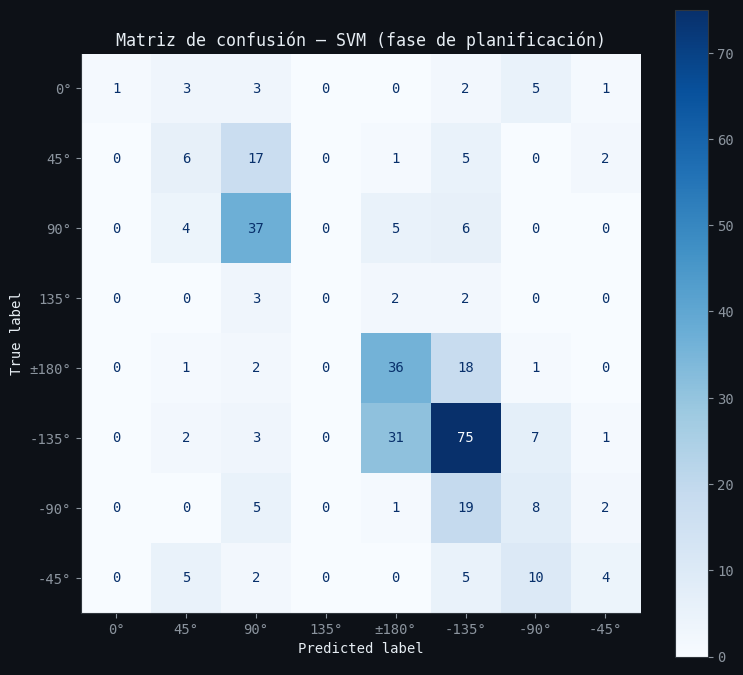

,Modelo,Accuracy,Precision Macro,Recall Macro,F1 Macro
0,SVM (RBF),0.486900,0.437400,0.325600,0.319000
1,LSTM (last+mean pool),0.419825,0.380023,0.387808,0.360896


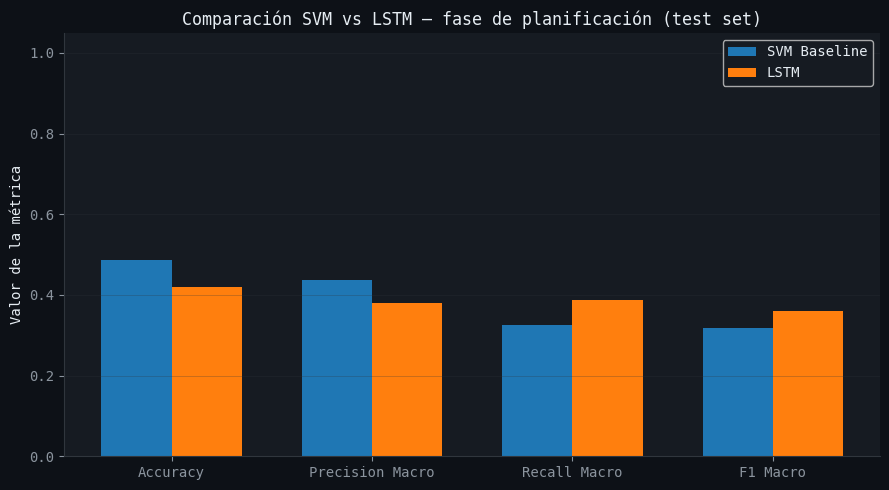

In [ ]:
#@title 5. Comparación
# ── Matriz de confusión SVM
cm_svm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=angles)
plt.figure(figsize=(8, 7))
disp.plot(cmap="Blues", values_format="d", ax=plt.gca())
plt.title("Matriz de confusión — SVM (fase de planificación)")
plt.tight_layout()
plt.show()

# ── Comparación SVM vs LSTM con resultados reales del test LSTM
# Extraídos de la matriz de confusión compartida
lstm_test = {
    "Accuracy":        accuracy_score(all_labels, all_preds),
    "Precision Macro": precision_score(all_labels, all_preds, average='macro', zero_division=0),
    "Recall Macro":    recall_score(all_labels, all_preds, average='macro', zero_division=0),
    "F1 Macro":        f1_score(all_labels, all_preds, average='macro', zero_division=0),
}

svm_test = {
    "Accuracy":        accuracy_score(y_test, y_test_pred),
    "Precision Macro": precision_score(y_test, y_test_pred, average='macro', zero_division=0),
    "Recall Macro":    recall_score(y_test, y_test_pred, average='macro', zero_division=0),
    "F1 Macro":        f1_score(y_test, y_test_pred, average='macro', zero_division=0),
}

tabla_comparacion = pd.DataFrame({
    "Modelo":          ["SVM (RBF)", "LSTM (last+mean pool)"],
    "Accuracy":        [round(svm_test["Accuracy"], 4),        lstm_test["Accuracy"]],
    "Precision Macro": [round(svm_test["Precision Macro"], 4), lstm_test["Precision Macro"]],
    "Recall Macro":    [round(svm_test["Recall Macro"], 4),    lstm_test["Recall Macro"]],
    "F1 Macro":        [round(svm_test["F1 Macro"], 4),        lstm_test["F1 Macro"]]
})
display(tabla_comparacion)

# ── Gráfico comparativo
metricas = ["Accuracy", "Precision Macro", "Recall Macro", "F1 Macro"]
x = np.arange(len(metricas))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, [svm_test[m] for m in metricas],  width, label="SVM Baseline")
plt.bar(x + width/2, [lstm_test[m] for m in metricas], width, label="LSTM")
plt.xticks(x, metricas)
plt.ylim(0, 1.05)
plt.ylabel("Valor de la métrica")
plt.title("Comparación SVM vs LSTM — fase de planificación (test set)")
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

Probabilidades: (343, 8)
Etiquetas reales: (343,)
Clases: ['0°', '45°', '90°', '135°', '±180°', '-135°', '-90°', '-45°']


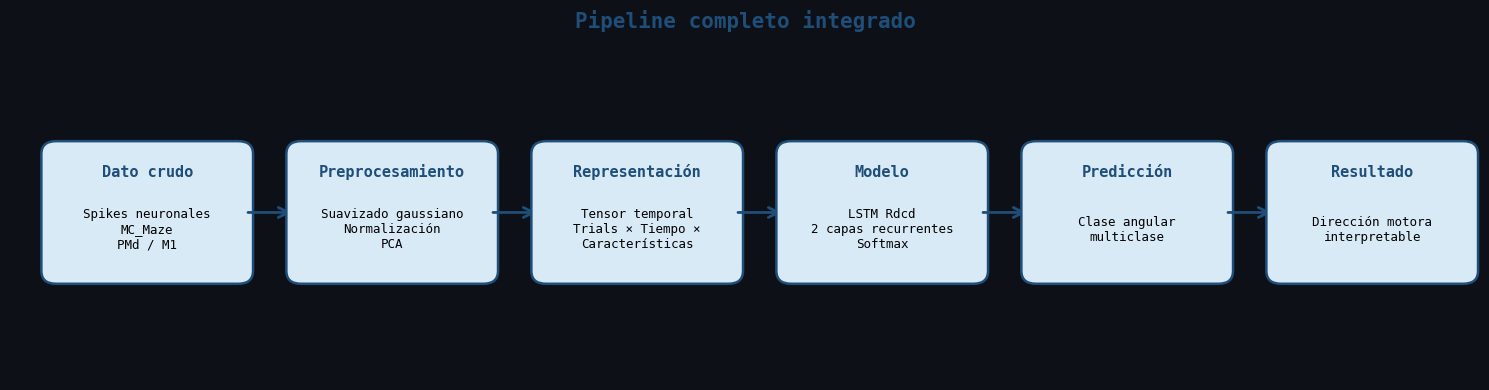

Etapa,Descripción
Dato crudo,Trenes de spikes neuronales registrados en MC_Maze
Preprocesamiento,"Suavizado gaussiano, normalización y reducción PCA"
Extracción / representación,Tensor temporal de actividad neuronal para LSTM
Modelo,Arquitectura LSTM Rdcd
Predicción,Clasificación multiclase por dirección angular
Resultado interpretable,Dirección motora estimada a partir de actividad neuronal


Elemento,Descripción
Entrada del sistema,Ventana de actividad neuronal de un trial
Tipo de señal,Spikes transformados a firing rates
Representación,Tensor temporal con 500 pasos y 69 características
Modelo final evaluado,LSTM Rdcd
Salida del sistema,Dirección angular predicha
Clases evaluadas,"0°, 45°, 90°, 135°, ±180°, -135°, -90°, -45°"


Métrica,Valor
Accuracy,0.419800
Sensibilidad / Recall Macro,0.387800
Precision Macro,0.380000
F1-score Macro,0.360900
AUC-ROC Macro,0.843800
AUC-ROC Micro,0.852500


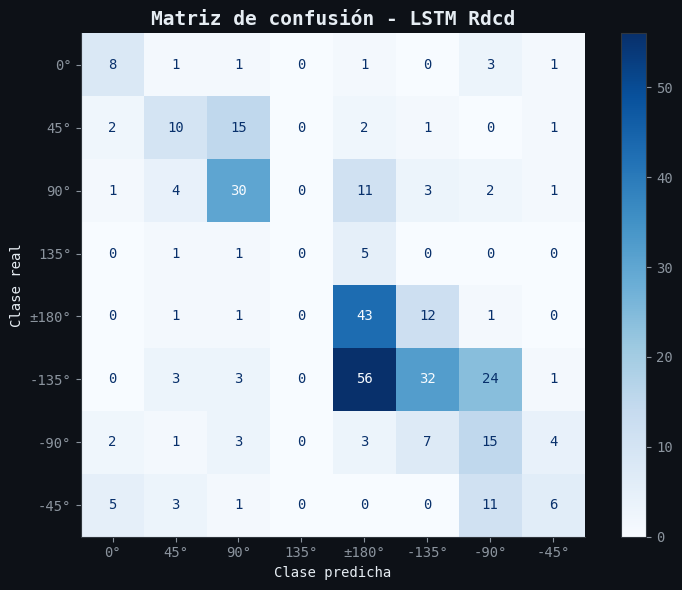

Clase angular,Accuracy clase,Sensibilidad,Especificidad,Precision,Recall,F1-score,AUC-ROC,Support
0°,0.950400,0.533300,0.969500,0.444400,0.533300,0.484800,0.855300,15
45°,0.898000,0.322600,0.955100,0.416700,0.322600,0.363600,0.873800,31
90°,0.863000,0.576900,0.914100,0.545500,0.576900,0.560700,0.889500,52
135°,0.979600,0.000000,1.000000,0.000000,0.000000,0.000000,0.783200,7
±180°,0.728900,0.741400,0.726300,0.355400,0.741400,0.480400,0.845900,58
-135°,0.679300,0.268900,0.897300,0.581800,0.268900,0.367800,0.761500,119
-90°,0.822200,0.428600,0.866900,0.267900,0.428600,0.329700,0.814900,35
-45°,0.918400,0.230800,0.974800,0.428600,0.230800,0.300000,0.926700,26


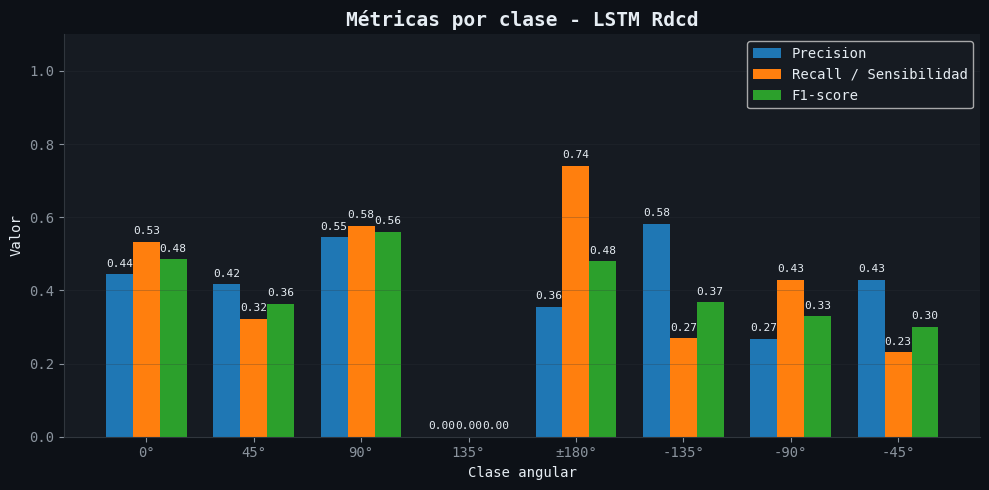

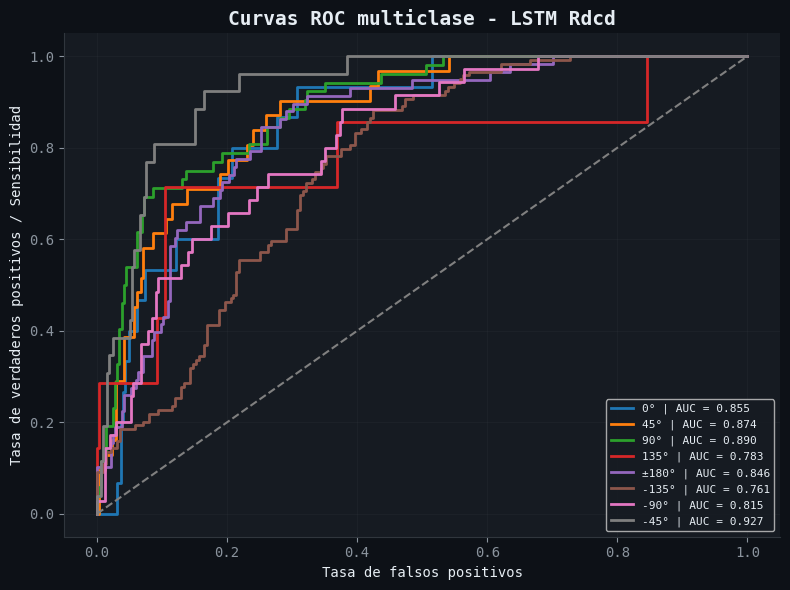

Modelo,Accuracy,Precision Macro,Recall Macro,F1-score Macro,Rol
SVM Baseline,0.486900,0.437400,0.325600,0.319000,Modelo baseline
LSTM Rdcd,0.419800,0.380000,0.387800,0.360900,Modelo temporal evaluado


Etapa,Descripción
Muestra evaluada,Trial interno de prueba índice 0
Entrada,Ventana de actividad neuronal del conjunto no visto
Preprocesamiento aplicado,Suavizado gaussiano + normalización + PCA
Representación,Tensor temporal de entrada a la LSTM
Modelo,LSTM Rdcd
Etiqueta real,0°
Predicción,0°
Probabilidad asociada,0.201400
Resultado interpretable,Clasificación correcta: dirección motora 0°


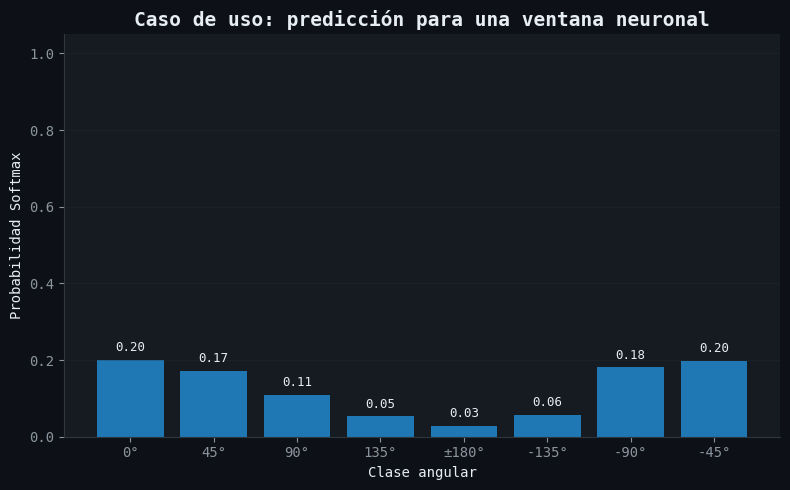

Ítem solicitado,Estado,Evidencia generada
Pipeline completo,Completado,Diagrama y tabla del pipeline
Descripción del sistema final,Completado,Tabla de entrada y salida del sistema
Resultados sobre conjunto no visto,Completado,Tabla de métricas globales y por clase
"Accuracy, sensibilidad, especificidad, precision, recall, F1",Completado,Tabla de métricas por clase
AUC-ROC,Completado,Curvas ROC multiclase
Matriz de confusión,Completado,Figura de matriz de confusión
Comparación de modelos,Completado,Tabla comparativa SVM vs LSTM
Caso de uso concreto,Completado,Tabla y gráfico de probabilidades Softmax


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import TensorDataset, DataLoader
from IPython.display import display
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve, auc
)
from sklearn.preprocessing import label_binarize
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

# ============================================================
# FUNCIÓN PARA TABLAS BONITAS
# ============================================================

def mostrar_tabla(df, titulo):
    display(
        df.style
        .hide(axis="index")
        .set_caption(titulo)
        .set_table_styles([
            {"selector": "caption",
             "props": [("font-size", "18px"),
                       ("font-weight", "bold"),
                       ("color", "#1f4e79"),
                       ("text-align", "center")]},
            {"selector": "th",
             "props": [("background-color", "#1f4e79"),
                       ("color", "white"),
                       ("font-weight", "bold"),
                       ("text-align", "center"),
                       ("border", "1px solid black")]},
            {"selector": "td",
             "props": [("text-align", "center"),
                       ("padding", "8px"),
                       ("border", "1px solid black")]},
            {"selector": "table",
             "props": [("border-collapse", "collapse"),
                       ("margin", "auto"),
                       ("width", "95%")]}
        ])
    )

# ============================================================
# 1. OBTENER PREDICCIONES Y PROBABILIDADES REALES
# ============================================================

# Si ya existen y_pred_prob, y_pred, y_true del AUC, se usan.
# Si no existen, se recalculan desde model, X_test_t, y_test_t.

try:
    y_pred_prob
    y_pred
    y_true
except NameError:
    model.eval()
    all_probs = []
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in DataLoader(
            TensorDataset(X_test_t, y_test_t),
            batch_size=BATCH_SIZE
        ):
            X_batch = X_batch.to(device)
            logits = model(X_batch)
            probs = torch.softmax(logits, dim=1)
            preds = probs.argmax(dim=1)

            all_probs.append(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    y_pred_prob = np.vstack(all_probs)
    y_pred = np.array(all_preds)
    y_true = np.array(all_labels)

n_classes = y_pred_prob.shape[1]
classes = np.arange(n_classes)

if "angles" in globals():
    class_labels = angles[:n_classes]
else:
    class_labels = ['0°', '45°', '90°', '135°', '±180°', '-135°', '-90°', '-45°'][:n_classes]

print("Probabilidades:", y_pred_prob.shape)
print("Etiquetas reales:", y_true.shape)
print("Clases:", class_labels)

# ============================================================
# 2. DIAGRAMA DE FLUJO DEL PIPELINE
# ============================================================

fig, ax = plt.subplots(figsize=(15, 4))
ax.set_xlim(0, 15)
ax.set_ylim(0, 4)
ax.axis("off")

steps = [
    ("Dato crudo", "Spikes neuronales\nMC_Maze\nPMd / M1"),
    ("Preprocesamiento", "Suavizado gaussiano\nNormalización\nPCA"),
    ("Representación", "Tensor temporal\nTrials × Tiempo ×\nCaracterísticas"),
    ("Modelo", "LSTM Rdcd\n2 capas recurrentes\nSoftmax"),
    ("Predicción", "Clase angular\nmulticlase"),
    ("Resultado", "Dirección motora\ninterpretable")
]

x_positions = [0.4, 2.9, 5.4, 7.9, 10.4, 12.9]
y_box = 1.2
box_w = 2.0
box_h = 1.5

for i, (title, desc) in enumerate(steps):
    x_pos = x_positions[i]

    box = FancyBboxPatch(
        (x_pos, y_box),
        box_w,
        box_h,
        boxstyle="round,pad=0.08,rounding_size=0.15",
        linewidth=1.8,
        edgecolor="#1f4e79",
        facecolor="#d9eaf7"
    )
    ax.add_patch(box)

    ax.text(
        x_pos + box_w/2,
        y_box + box_h - 0.28,
        title,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold",
        color="#1f4e79"
    )

    ax.text(
        x_pos + box_w/2,
        y_box + 0.55,
        desc,
        ha="center",
        va="center",
        fontsize=9,
        color="black"
    )

    if i < len(steps) - 1:
        arrow = FancyArrowPatch(
            (x_pos + box_w, y_box + box_h/2),
            (x_positions[i+1], y_box + box_h/2),
            arrowstyle="->",
            mutation_scale=18,
            linewidth=2,
            color="#1f4e79"
        )
        ax.add_patch(arrow)

plt.title("Pipeline completo integrado", fontsize=15, fontweight="bold", color="#1f4e79")
plt.tight_layout()
plt.show()

# ============================================================
# 3. TABLA DEL PIPELINE
# ============================================================

tabla_pipeline = pd.DataFrame({
    "Etapa": [
        "Dato crudo",
        "Preprocesamiento",
        "Extracción / representación",
        "Modelo",
        "Predicción",
        "Resultado interpretable"
    ],
    "Descripción": [
        "Trenes de spikes neuronales registrados en MC_Maze",
        "Suavizado gaussiano, normalización y reducción PCA",
        "Tensor temporal de actividad neuronal para LSTM",
        "Arquitectura LSTM Rdcd",
        "Clasificación multiclase por dirección angular",
        "Dirección motora estimada a partir de actividad neuronal"
    ]
})

mostrar_tabla(tabla_pipeline, "Tabla 1. Pipeline completo de extremo a extremo")

# ============================================================
# 4. DESCRIPCIÓN DEL SISTEMA FINAL
# ============================================================

tabla_sistema = pd.DataFrame({
    "Elemento": [
        "Entrada del sistema",
        "Tipo de señal",
        "Representación",
        "Modelo final evaluado",
        "Salida del sistema",
        "Clases evaluadas"
    ],
    "Descripción": [
        "Ventana de actividad neuronal de un trial",
        "Spikes transformados a firing rates",
        f"Tensor temporal con {X_test_t.shape[1]} pasos y {X_test_t.shape[2]} características",
        "LSTM Rdcd",
        "Dirección angular predicha",
        ", ".join(class_labels)
    ]
})

mostrar_tabla(tabla_sistema, "Tabla 2. Descripción del sistema final")

# ============================================================
# 5. MÉTRICAS GLOBALES
# ============================================================

accuracy = accuracy_score(y_true, y_pred)
precision_macro = precision_score(y_true, y_pred, average="macro", zero_division=0)
recall_macro = recall_score(y_true, y_pred, average="macro", zero_division=0)
f1_macro = f1_score(y_true, y_pred, average="macro", zero_division=0)

y_true_bin = label_binarize(y_true, classes=classes)

try:
    auc_macro = roc_auc_score(y_true_bin, y_pred_prob, average="macro", multi_class="ovr")
    auc_micro = roc_auc_score(y_true_bin, y_pred_prob, average="micro", multi_class="ovr")
except Exception:
    auc_macro = np.nan
    auc_micro = np.nan

tabla_metricas_globales = pd.DataFrame({
    "Métrica": [
        "Accuracy",
        "Sensibilidad / Recall Macro",
        "Precision Macro",
        "F1-score Macro",
        "AUC-ROC Macro",
        "AUC-ROC Micro"
    ],
    "Valor": [
        round(accuracy, 4),
        round(recall_macro, 4),
        round(precision_macro, 4),
        round(f1_macro, 4),
        round(auc_macro, 4) if not np.isnan(auc_macro) else "No calculable",
        round(auc_micro, 4) if not np.isnan(auc_micro) else "No calculable"
    ]
})

mostrar_tabla(tabla_metricas_globales, "Tabla 3. Resultados globales sobre conjunto de prueba")

# ============================================================
# 6. MATRIZ DE CONFUSIÓN
# ============================================================

cm_final = confusion_matrix(y_true, y_pred, labels=classes)

fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_final,
    display_labels=class_labels
)
disp.plot(cmap="Blues", values_format="d", ax=ax, colorbar=True)
plt.title("Matriz de confusión - LSTM Rdcd", fontsize=14, fontweight="bold")
plt.xlabel("Clase predicha")
plt.ylabel("Clase real")
plt.grid(False)
plt.tight_layout()
plt.show()

# ============================================================
# 7. MÉTRICAS POR CLASE
# ============================================================

metricas_clase = []
total = np.sum(cm_final)

fpr = {}
tpr = {}
roc_auc = {}

for i in range(n_classes):
    if len(np.unique(y_true_bin[:, i])) == 2:
        fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_prob[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
    else:
        fpr[i], tpr[i] = None, None
        roc_auc[i] = np.nan

for i, label in enumerate(class_labels):
    TP = cm_final[i, i]
    FN = np.sum(cm_final[i, :]) - TP
    FP = np.sum(cm_final[:, i]) - TP
    TN = total - TP - FN - FP

    acc_clase = (TP + TN) / total if total > 0 else 0
    sensibilidad = TP / (TP + FN) if (TP + FN) > 0 else 0
    especificidad = TN / (TN + FP) if (TN + FP) > 0 else 0
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = sensibilidad
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    support = TP + FN

    metricas_clase.append({
        "Clase angular": label,
        "Accuracy clase": round(acc_clase, 4),
        "Sensibilidad": round(sensibilidad, 4),
        "Especificidad": round(especificidad, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-score": round(f1, 4),
        "AUC-ROC": round(roc_auc[i], 4) if not np.isnan(roc_auc[i]) else "No calculable",
        "Support": int(support)
    })

tabla_metricas_clase = pd.DataFrame(metricas_clase)

mostrar_tabla(tabla_metricas_clase, "Tabla 4. Métricas por clase del modelo LSTM Rdcd")

# ============================================================
# 8. GRÁFICO DE MÉTRICAS POR CLASE
# ============================================================

precision_vals = tabla_metricas_clase["Precision"].astype(float).values
recall_vals = tabla_metricas_clase["Recall"].astype(float).values
f1_vals = tabla_metricas_clase["F1-score"].astype(float).values

x = np.arange(len(class_labels))
width = 0.25

plt.figure(figsize=(10, 5))
b1 = plt.bar(x - width, precision_vals, width, label="Precision")
b2 = plt.bar(x, recall_vals, width, label="Recall / Sensibilidad")
b3 = plt.bar(x + width, f1_vals, width, label="F1-score")

plt.xticks(x, class_labels)
plt.ylim(0, 1.1)
plt.xlabel("Clase angular")
plt.ylabel("Valor")
plt.title("Métricas por clase - LSTM Rdcd", fontsize=14, fontweight="bold")
plt.legend()
plt.grid(axis="y", alpha=0.3)

for bars in [b1, b2, b3]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.015,
            f"{height:.2f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.tight_layout()
plt.show()

# ============================================================
# 9. CURVAS ROC MULTICLASE
# ============================================================

plt.figure(figsize=(8, 6))

for i in range(n_classes):
    if fpr[i] is not None:
        plt.plot(
            fpr[i],
            tpr[i],
            linewidth=2,
            label=f"{class_labels[i]} | AUC = {roc_auc[i]:.3f}"
        )

plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
plt.xlabel("Tasa de falsos positivos")
plt.ylabel("Tasa de verdaderos positivos / Sensibilidad")
plt.title("Curvas ROC multiclase - LSTM Rdcd", fontsize=14, fontweight="bold")
plt.legend(loc="lower right", fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 10. COMPARACIÓN DE MODELOS
# ============================================================

# Si existe SVM del notebook, usa sus resultados reales.
if "y_test_pred" in globals() and "y_test" in globals():
    svm_accuracy = accuracy_score(y_test, y_test_pred)
    svm_precision = precision_score(y_test, y_test_pred, average="macro", zero_division=0)
    svm_recall = recall_score(y_test, y_test_pred, average="macro", zero_division=0)
    svm_f1 = f1_score(y_test, y_test_pred, average="macro", zero_division=0)
else:
    svm_accuracy = np.nan
    svm_precision = np.nan
    svm_recall = np.nan
    svm_f1 = np.nan

tabla_comparacion = pd.DataFrame({
    "Modelo": ["SVM Baseline", "LSTM Rdcd"],
    "Accuracy": [
        round(svm_accuracy, 4) if not np.isnan(svm_accuracy) else "No ejecutado",
        round(accuracy, 4)
    ],
    "Precision Macro": [
        round(svm_precision, 4) if not np.isnan(svm_precision) else "No ejecutado",
        round(precision_macro, 4)
    ],
    "Recall Macro": [
        round(svm_recall, 4) if not np.isnan(svm_recall) else "No ejecutado",
        round(recall_macro, 4)
    ],
    "F1-score Macro": [
        round(svm_f1, 4) if not np.isnan(svm_f1) else "No ejecutado",
        round(f1_macro, 4)
    ],
    "Rol": [
        "Modelo baseline",
        "Modelo temporal evaluado"
    ]
})

mostrar_tabla(tabla_comparacion, "Tabla 5. Comparación de modelos evaluados")

# ============================================================
# 11. CASO DE USO CONCRETO REAL
# ============================================================

# Selecciona una muestra bien clasificada.
candidate_idxs = np.where(y_true == y_pred)[0]

if len(candidate_idxs) > 0:
    idx_case = int(candidate_idxs[0])
else:
    idx_case = 0

real_idx = int(y_true[idx_case])
pred_idx = int(y_pred[idx_case])

real_label = class_labels[real_idx]
pred_label = class_labels[pred_idx]
prob_pred = float(y_pred_prob[idx_case, pred_idx])

resultado = "Clasificación correcta" if real_idx == pred_idx else "Clasificación incorrecta"

tabla_caso_uso = pd.DataFrame({
    "Etapa": [
        "Muestra evaluada",
        "Entrada",
        "Preprocesamiento aplicado",
        "Representación",
        "Modelo",
        "Etiqueta real",
        "Predicción",
        "Probabilidad asociada",
        "Resultado interpretable"
    ],
    "Descripción": [
        f"Trial interno de prueba índice {idx_case}",
        "Ventana de actividad neuronal del conjunto no visto",
        "Suavizado gaussiano + normalización + PCA",
        "Tensor temporal de entrada a la LSTM",
        "LSTM Rdcd",
        real_label,
        pred_label,
        round(prob_pred, 4),
        f"{resultado}: dirección motora {pred_label}"
    ]
})

mostrar_tabla(tabla_caso_uso, "Tabla 6. Caso de uso concreto: ventana neuronal clasificada")

plt.figure(figsize=(8, 5))
bars = plt.bar(class_labels, y_pred_prob[idx_case])
plt.ylim(0, 1.05)
plt.xlabel("Clase angular")
plt.ylabel("Probabilidad Softmax")
plt.title("Caso de uso: predicción para una ventana neuronal", fontsize=14, fontweight="bold")
plt.grid(axis="y", alpha=0.3)

for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.015,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.tight_layout()
plt.show()

# ============================================================
# 12. RESUMEN DE CUMPLIMIENTO DE LA RÚBRICA
# ============================================================

tabla_resumen = pd.DataFrame({
    "Ítem solicitado": [
        "Pipeline completo",
        "Descripción del sistema final",
        "Resultados sobre conjunto no visto",
        "Accuracy, sensibilidad, especificidad, precision, recall, F1",
        "AUC-ROC",
        "Matriz de confusión",
        "Comparación de modelos",
        "Caso de uso concreto"
    ],
    "Estado": [
        "Completado",
        "Completado",
        "Completado",
        "Completado",
        "Completado" if not np.isnan(auc_macro) else "No calculable",
        "Completado",
        "Completado",
        "Completado"
    ],
    "Evidencia generada": [
        "Diagrama y tabla del pipeline",
        "Tabla de entrada y salida del sistema",
        "Tabla de métricas globales y por clase",
        "Tabla de métricas por clase",
        "Curvas ROC multiclase",
        "Figura de matriz de confusión",
        "Tabla comparativa SVM vs LSTM",
        "Tabla y gráfico de probabilidades Softmax"
    ]
})

mostrar_tabla(tabla_resumen, "Tabla 7. Verificación de cumplimiento de requisitos")

In [ ]:
# ============================================================
# TABLA: JUSTIFICACIÓN DE SELECCIÓN DEL MODELO FINAL
# ============================================================

tabla_seleccion_modelo = pd.DataFrame({
    "Criterio": [
        "Accuracy",
        "Precision Macro",
        "Recall Macro",
        "F1-score Macro",
        "Modelado temporal",
        "Procesamiento de secuencias",
        "Adecuación a señales neuronales",
        "Modelo seleccionado"
    ],
    "SVM (RBF)": [
        "0.4869",
        "0.4374",
        "0.3256",
        "0.3190",
        "No",
        "Limitado",
        "Media",
        ""
    ],
    "LSTM Rdcd": [
        "0.4198",
        "0.3800",
        "0.3878",
        "0.3609",
        "Sí",
        "Alta",
        "Alta",
        "✓"
    ]
})

mostrar_tabla(
    tabla_seleccion_modelo,
    "Tabla 6. Justificación de selección del modelo final"
)

Criterio,SVM (RBF),LSTM Rdcd
Accuracy,0.4869,0.4198
Precision Macro,0.4374,0.3800
Recall Macro,0.3256,0.3878
F1-score Macro,0.3190,0.3609
Modelado temporal,No,Sí
Procesamiento de secuencias,Limitado,Alta
Adecuación a señales neuronales,Media,Alta
Modelo seleccionado,,✓
